# 岭回归不对截距项做正则化 精简推导
## 一、损失函数
仅惩罚系数$\theta_1\sim\theta_p$，不约束截距$\theta_0$
$$
L(\theta)=\frac{1}{N}\sum_{i=1}^N\Big(\theta_0+\sum_{j=1}^p\theta_j z_i^j-y_i\Big)^2+\lambda\sum_{j=1}^p\theta_j^2
$$
若一并正则截距，形式为：
$$
L_{\text{wrong}}(\theta)=\frac{1}{N}\|\Phi\theta-y\|_2^2+\lambda\|\theta\|_2^2
$$

## 二、矩阵形式与正则矩阵
拆分参数与设计矩阵
$$
\theta=\begin{bmatrix}\theta_0\\\boldsymbol{\beta}\end{bmatrix},\quad
\Phi=\begin{bmatrix}\boldsymbol 1 & Z\end{bmatrix}
$$
正则项改写：
$$
\lambda\boldsymbol\beta^\text{T}\boldsymbol\beta=\lambda\theta^\text{T}R\theta
$$
正则对角矩阵
$$
R=
\begin{bmatrix}
0 & & \\
& \boldsymbol I_p & \\
\end{bmatrix}
$$
$R_{00}=0$，代表截距无惩罚。

整体损失矩阵表达式
$$
L(\theta)=\frac{1}{N}(\Phi\theta-y)^\text{T}(\Phi\theta-y)+\lambda\theta^\text{T}R\theta
$$

## 三、求导推导正规方程
梯度
$$
\nabla_\theta L=\frac{2}{N}\Phi^\text{T}(\Phi\theta-y)+2\lambda R\theta
$$
令梯度为0：
$$
\frac{2}{N}\Phi^\text{T}(\Phi\theta-y)+2\lambda R\theta=0
$$
约去系数整理
$$
\Big(\frac{\Phi^\text{T}\Phi}{N}+\lambda R\Big)\theta=\frac{\Phi^\text{T}y}{N}
$$

若错误正则全部参数，取$R=I$：
$$
\Big(\frac{\Phi^\text{T}\Phi}{N}+\lambda I\Big)\theta=\frac{\Phi^\text{T}y}{N}
$$
该式仅中心化数据可用。

## 四、不惩罚截距的原因
1. 几何意义
截距仅平移曲线，不改变模型复杂度；系数大小决定拟合波动程度，只需惩罚系数。

2. 最优截距性质
对$\theta_0$求导置零，得
$$
\theta_0=\bar y-\sum_{j=1}^p\theta_j\overline{z^j}
$$
$\theta_0$取值与$\lambda$无关，额外惩罚会引入估计偏差。

3. 极简实例
仅保留截距项$\hat y=\theta_0$，无正则解$\theta_0=\bar y$。
加入惩罚后求解：
$$
\theta_0=\frac{\bar y}{1+N\lambda}
$$
参数被压缩偏离真实均值，估计失效。

## 五、数据中心化补充
特征与标签中心化后，等效截距归零，此时可用单位阵正则计算，仅为计算便捷，本质仍不对原始截距施加惩罚。

## 六、小结
1. $R_{00}=0$实现截距免正则，仅约束高阶系数；
2. 求导推导得到岭回归标准求解方程；
3. 截距不影响模型复杂度，正则会造成估计偏差；
4. 单位阵正则形式仅适配中心化数据集。

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining
Figure directory: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures


In [4]:
N = 80
noise_std = 0.20

x = np.linspace(-3, 3, N)
y_clean = np.sin(x)

epsilon = noise_std * np.random.randn(N)
y = y_clean + epsilon

print("x shape:", x.shape)
print("y_clean shape:", y_clean.shape)
print("epsilon shape:", epsilon.shape)
print("y shape:", y.shape)

x shape: (80,)
y_clean shape: (80,)
epsilon shape: (80,)
y shape: (80,)


In [6]:
indices = np.random.permutation(N)

n_train = int(0.6 * N)
n_val = int(0.2 * N)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

x_train = x[train_idx]
y_train = y[train_idx]

x_val = x[val_idx]
y_val = y[val_idx]

x_test = x[test_idx]
y_test = y[test_idx]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (48,)
y_train shape: (48,)
x_val shape: (16,)
y_val shape: (16,)
x_test shape: (16,)
y_test shape: (16,)


In [8]:
def make_polynomial_features(x_values, poly_degree, x_scale=3.0):
    """
    Construct polynomial design matrix:
    [1, z, z^2, ..., z^poly_degree]
    where z = x / x_scale.
    """
    x_values = np.asarray(x_values)
    z = x_values / x_scale

    columns = []

    for power in range(poly_degree + 1):
        columns.append(z ** power)

    Phi = np.column_stack(columns)

    expected_num_columns = poly_degree + 1

    assert Phi.shape[1] == expected_num_columns, (
        f"Expected {expected_num_columns} columns, got {Phi.shape[1]}"
    )

    return Phi

In [10]:
for test_degree in [1, 2, 3, 10, 20]:
    Phi_check = make_polynomial_features(x_test, test_degree)
    print("degree:", test_degree, "Phi shape:", Phi_check.shape)

degree: 1 Phi shape: (16, 2)
degree: 2 Phi shape: (16, 3)
degree: 3 Phi shape: (16, 4)
degree: 10 Phi shape: (16, 11)
degree: 20 Phi shape: (16, 21)


In [12]:
def mse(y_true, y_pred):
    errors = y_pred - y_true
    return np.mean(errors ** 2)

In [20]:
def fit_ridge(Phi, y, reg_strength):
    """
    Fit ridge regression.

    For reg_strength = 0, use ordinary least squares.
    For reg_strength > 0, solve:

        ((Phi.T @ Phi) / N + lambda * R) theta = (Phi.T @ y) / N

    The intercept coefficient theta[0] is not regularised.
    """

    n_samples, n_features = Phi.shape

    if reg_strength == 0.0:
        theta_hat, residual, rank, singular_values = np.linalg.lstsq(Phi,y,rcond=None)
        return theta_hat

    regularisation_matrix = np.eye(n_features)
    regularisation_matrix[0,0] = 0.0

    A = (Phi.T @ Phi) / n_samples + reg_strength * regularisation_matrix
    rhs = (Phi.T @ y) / n_samples

    theta_hat = np.linalg.solve(A, rhs)

    return theta_hat

In [36]:
ridge_degree = 20

reg_strengths = [0.0, 1e-6, 1e-3, 1e-1, 1.0, 10.0]

Phi_train = make_polynomial_features(x_train, ridge_degree)
Phi_val = make_polynomial_features(x_val, ridge_degree)
Phi_test = make_polynomial_features(x_test, ridge_degree)

print("Phi_train shape:", Phi_train.shape)
print("Phi_val shape:", Phi_val.shape)
print("Phi_test shape:", Phi_test.shape)

Phi_train shape: (48, 21)
Phi_val shape: (16, 21)
Phi_test shape: (16, 21)


In [38]:
ridge_results = {}

for reg_strength in reg_strengths:
    theta_hat = fit_ridge(Phi_train, y_train, reg_strength)

    y_pred_train = Phi_train @ theta_hat
    y_pred_val = Phi_val @ theta_hat

    train_mse = mse(y_train, y_pred_train)
    val_mse = mse(y_val, y_pred_val)

    coefficient_norm = np.linalg.norm(theta_hat[1:])

    ridge_results[reg_strength] = {"theta_hat":theta_hat, "train_mse":train_mse, "val_mse": val_mse, "coefficient_norm":coefficient_norm}

    print("lambda:", reg_strength)
    print("  theta_hat shape:", theta_hat.shape)
    print("  Train MSE:", train_mse)
    print("  Validation MSE:", val_mse)
    print("  coefficient norm excluding intercept:", coefficient_norm)
    print()

lambda: 0.0
  theta_hat shape: (21,)
  Train MSE: 0.025345961941554317
  Validation MSE: 3.3387095457560627
  coefficient norm excluding intercept: 205964.94700763948

lambda: 1e-06
  theta_hat shape: (21,)
  Train MSE: 0.030274195335542837
  Validation MSE: 0.043685846195968187
  coefficient norm excluding intercept: 15.945986740503919

lambda: 0.001
  theta_hat shape: (21,)
  Train MSE: 0.0359990089215941
  Validation MSE: 0.035644827428390244
  coefficient norm excluding intercept: 3.2907773263259763

lambda: 0.1
  theta_hat shape: (21,)
  Train MSE: 0.15741104818608948
  Validation MSE: 0.1540653752987637
  coefficient norm excluding intercept: 0.8883159505794578

lambda: 1.0
  theta_hat shape: (21,)
  Train MSE: 0.3503969846737604
  Validation MSE: 0.37696173193963567
  coefficient norm excluding intercept: 0.222371174806774

lambda: 10.0
  theta_hat shape: (21,)
  Train MSE: 0.4502014949492335
  Validation MSE: 0.4950157852568934
  coefficient norm excluding intercept: 0.03023789

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp5_ridge_fitted_curves.png


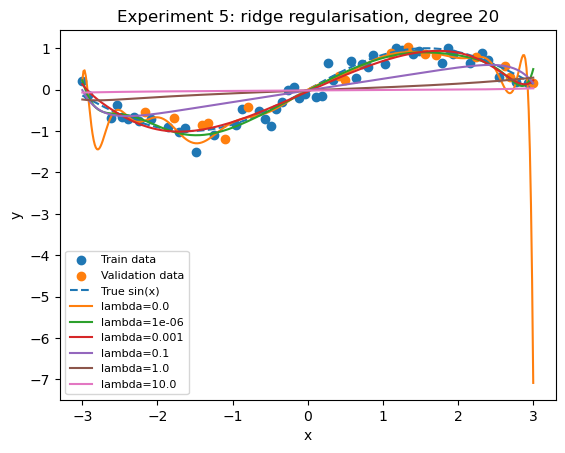

In [40]:
x_plot = np.linspace(-3, 3, 400)
y_clean_plot = np.sin(x_plot)

fig, ax = plt.subplots()

ax.scatter(x_train, y_train, label="Train data")
ax.scatter(x_val, y_val, label="Validation data")
ax.plot(x_plot, y_clean_plot, linestyle="--", label="True sin(x)")

Phi_plot = make_polynomial_features(x_plot, ridge_degree)

for reg_strength in reg_strengths:
    theta_hat = ridge_results[reg_strength]["theta_hat"]
    y_plot = Phi_plot @ theta_hat

    ax.plot(x_plot, y_plot, label=f"lambda={reg_strength}")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Experiment 5: ridge regularisation, degree 20")
ax.legend(fontsize=8)

fig_path = FIGURE_DIR / "exp5_ridge_fitted_curves.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp5_mse_vs_lambda.png


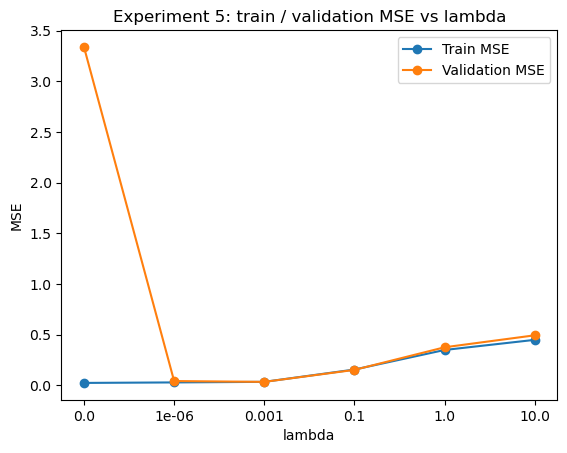

In [28]:
lambda_labels = [str(value) for value in reg_strengths]

train_mse_values = [ridge_results[value]["train_mse"] for value in reg_strengths]
val_mse_values = [ridge_results[value]["val_mse"] for value in reg_strengths]

positions = np.arange(len(reg_strengths))

fig, ax = plt.subplots()

ax.plot(positions, train_mse_values, marker="o", label="Train MSE")
ax.plot(positions, val_mse_values, marker="o", label="Validation MSE")

ax.set_xticks(positions)
ax.set_xticklabels(lambda_labels)
ax.set_xlabel("lambda")
ax.set_ylabel("MSE")
ax.set_title("Experiment 5: train / validation MSE vs lambda")
ax.legend()

fig_path = FIGURE_DIR / "exp5_mse_vs_lambda.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp5_coefficient_norm_vs_lambda.png


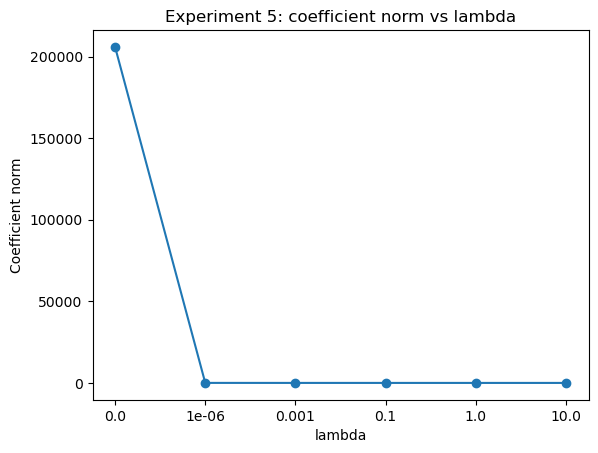

In [30]:
coefficient_norms = [
    ridge_results[value]["coefficient_norm"]
    for value in reg_strengths
]

positions = np.arange(len(reg_strengths))

fig, ax = plt.subplots()

ax.plot(positions, coefficient_norms, marker="o")

ax.set_xticks(positions)
ax.set_xticklabels(lambda_labels)
ax.set_xlabel("lambda")
ax.set_ylabel("Coefficient norm")
ax.set_title("Experiment 5: coefficient norm vs lambda")

fig_path = FIGURE_DIR / "exp5_coefficient_norm_vs_lambda.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [32]:
best_lambda = min(
    reg_strengths,
    key=lambda reg_strength: ridge_results[reg_strength]["val_mse"]
)

theta_best = ridge_results[best_lambda]["theta_hat"]

print("Best lambda by validation MSE:", best_lambda)
print("theta_best shape:", theta_best.shape)

Best lambda by validation MSE: 0.001
theta_best shape: (21,)


In [34]:
y_pred_test = Phi_test @ theta_best
test_mse = mse(y_test, y_pred_test)

print("Best lambda by validation MSE:", best_lambda)
print("Train MSE at best lambda:", ridge_results[best_lambda]["train_mse"])
print("Validation MSE at best lambda:", ridge_results[best_lambda]["val_mse"])
print("Test MSE at best lambda:", test_mse)
print("y_pred_test shape:", y_pred_test.shape)

Best lambda by validation MSE: 0.001
Train MSE at best lambda: 0.0359990089215941
Validation MSE at best lambda: 0.035644827428390244
Test MSE at best lambda: 0.042988555619396
y_pred_test shape: (16,)


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp5_best_model_prediction_vs_truth.png


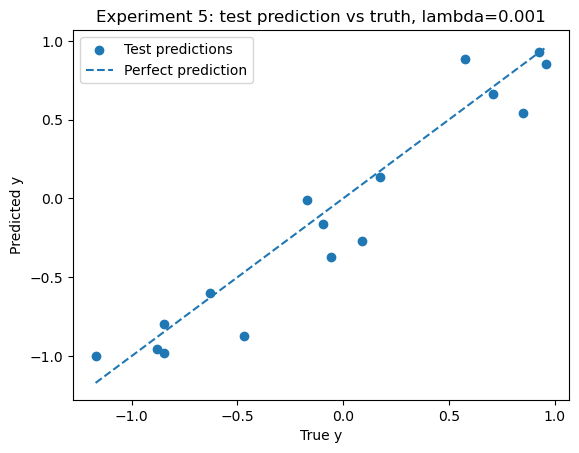

In [42]:
fig, ax = plt.subplots()

ax.scatter(y_test, y_pred_test, label="Test predictions")

min_value = min(y_test.min(), y_pred_test.min())
max_value = max(y_test.max(), y_pred_test.max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

ax.set_xlabel("True y")
ax.set_ylabel("Predicted y")
ax.set_title(f"Experiment 5: test prediction vs truth, lambda={best_lambda}")
ax.legend()

fig_path = FIGURE_DIR / "exp5_best_model_prediction_vs_truth.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()